In [106]:
import torch
from torch import nn
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [107]:
weight = 0.3
bias = 0.9

start = 0
end = 1
step = 0.01

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X.shape, y.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [108]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X_train.device

device(type='cpu')

In [109]:
def plot_predictions(train_data = X_train, test_data = X_test, train_labels = y_train, test_labels = y_test, prediction=None):
    
    plt.figure(figsize=(10, 7))
    
    plt.scatter(train_data, train_labels, color="b", s=4, label="Training Data")
    
    plt.scatter(test_data, test_labels, color="g", s=4, label="Test Data")
    
    if prediction is not None:
        
        plt.scatter(test_data, prediction, color="r", s=4, label="Prediction")
        
    plt.legend(prop={"size": 14})

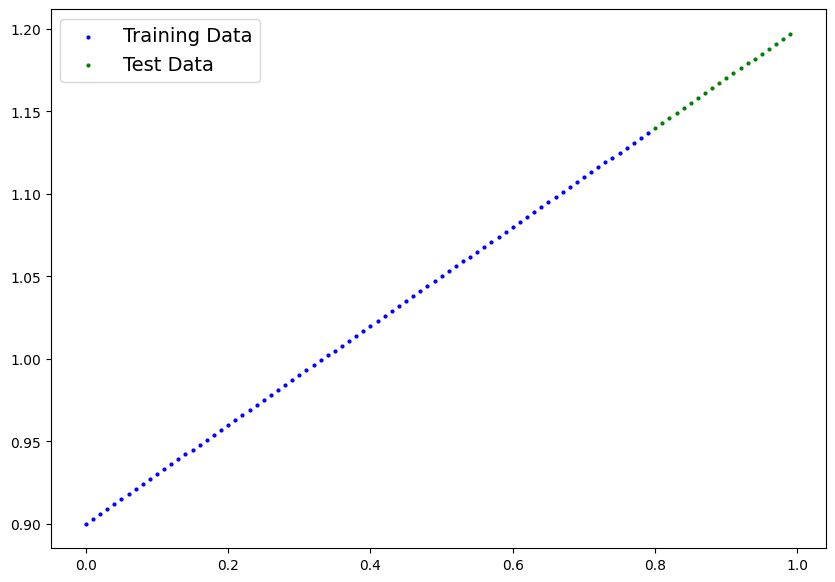

In [110]:
plot_predictions()

In [111]:
class LinearModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.linearLayer = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linearLayer(x)

In [112]:
torch.manual_seed(42)

model = LinearModel()
model.to(device)

model.state_dict()

OrderedDict([('linearLayer.weight', tensor([[0.7645]], device='cuda:0')),
             ('linearLayer.bias', tensor([0.8300], device='cuda:0'))])

In [113]:
next(model.parameters()).device

device(type='cuda', index=0)

In [114]:
lossfn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [115]:
epochs = 300

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    
    model.train()
    
    y_pred = model(X_train)
    
    train_loss = lossfn(y_pred, y_train)
    
    optimizer.zero_grad()
    
    train_loss.backward()
    
    optimizer.step()
    
    model.eval()
    
    with torch.inference_mode():
        
        test_pred = model(X_test) 
        test_loss = lossfn(test_pred, y_test.type(torch.float))
        
        if epoch % 20 == 0:
            print(f"Epoch: {epoch}  |   Train Loss: {train_loss}    |   Test Loss: {test_loss}")
            

Epoch: 0  |   Train Loss: 0.1275613158941269    |   Test Loss: 0.33650314807891846
Epoch: 20  |   Train Loss: 0.08187223970890045    |   Test Loss: 0.21840262413024902
Epoch: 40  |   Train Loss: 0.07207288593053818    |   Test Loss: 0.17458660900592804
Epoch: 60  |   Train Loss: 0.06507988274097443    |   Test Loss: 0.15310420095920563
Epoch: 80  |   Train Loss: 0.05822876840829849    |   Test Loss: 0.1367770880460739
Epoch: 100  |   Train Loss: 0.05137667804956436    |   Test Loss: 0.12079393863677979
Epoch: 120  |   Train Loss: 0.04452557489275932    |   Test Loss: 0.10446684807538986
Epoch: 140  |   Train Loss: 0.0376744270324707    |   Test Loss: 0.08813951909542084
Epoch: 160  |   Train Loss: 0.03082224726676941    |   Test Loss: 0.0721558928489685
Epoch: 180  |   Train Loss: 0.02397105097770691    |   Test Loss: 0.055828340351581573
Epoch: 200  |   Train Loss: 0.017119847238063812    |   Test Loss: 0.03950077295303345
Epoch: 220  |   Train Loss: 0.010267681442201138    |   Test L

In [116]:
model.eval()

with torch.inference_mode():
    
    y_preds = model(X_test)

model.state_dict(), y_preds

(OrderedDict([('linearLayer.weight', tensor([[0.3028]], device='cuda:0')),
              ('linearLayer.bias', tensor([0.8910], device='cuda:0'))]),
 tensor([[1.1333],
         [1.1363],
         [1.1393],
         [1.1423],
         [1.1454],
         [1.1484],
         [1.1514],
         [1.1545],
         [1.1575],
         [1.1605],
         [1.1635],
         [1.1666],
         [1.1696],
         [1.1726],
         [1.1757],
         [1.1787],
         [1.1817],
         [1.1847],
         [1.1878],
         [1.1908]], device='cuda:0'))

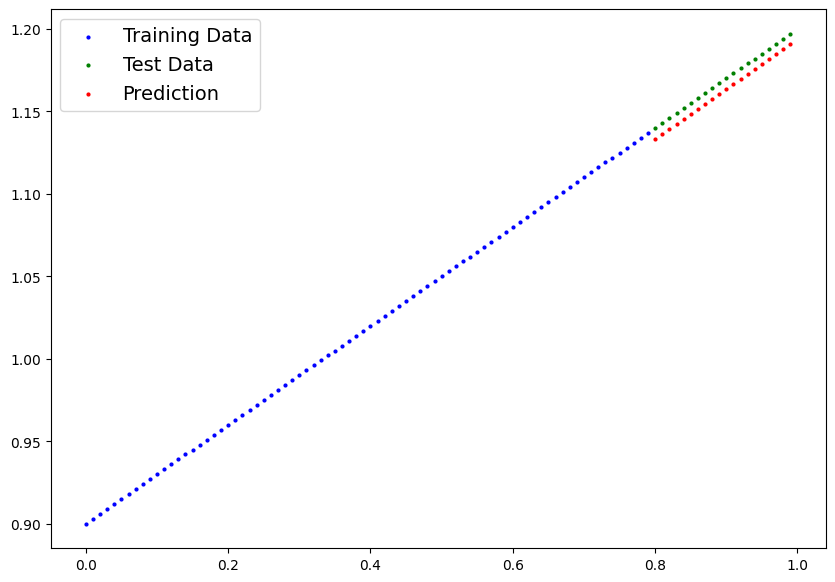

In [117]:
plot_predictions(prediction=y_preds.cpu())

In [118]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_exercise_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_exercise_model.pth
